# 02. 정수와 유리수: 기준, 균형, 그리고 비율의 조화

본 노트북은 정수와 유리수 단원의 철학적 의미인 **기준(0), 대칭(음수), 그리고 비율(유리수)**을 파이썬 시각화 도구로 직접 구현하고 느끼기 위해 기획되었습니다.

## 1. 학습 목표
1. **유리수의 조밀성(Density)**을 수직선 상에 시각화하여, 유리수가 수직선에 촘촘히 채워지는 양상과 그 사이에 깃든 무리수의 빈틈을 시각적으로 탐색합니다.
2. **피타고라스 화음(Pythagorean Harmonics)**을 물리적 파동으로 합성하고 중첩해 봄으로써, 정수비(유리수)를 가진 음률이 어떻게 아름다운 시각적 주기성과 협화음을 만드는지 직접 보고 듣습니다.


## 실습 1. 유리수의 조밀성 (Density of Rational Numbers)

유리수는 아무리 좁은 두 유리수 사이를 잡아도 그 안에 무한히 많은 유리수가 존재하는 **조밀성(Density)**을 가집니다.
아래 코드는 분모 $q$를 $1$부터 $N$까지 증가시키며 가능한 모든 기약분수 $p/q$를 $x$축에 찍고, 분모 $q$를 $y$축에 정렬하여 유리수가 채워지는 분포를 보여줍니다.
여기에 유리수가 아닌 대표적인 무리수 $\frac{1}{\sqrt{2}} \approx 0.7071$을 수직선으로 표시하여, 유리수의 무한한 조밀함 속에서도 결코 닿을 수 없는 '무리수의 빈틈'을 확인해 봅니다.


In [4]:
# ① 라이브러리 임포트 (가져오기)
import matplotlib.pyplot as plt # 그래프나 도표 사용지원 대표적 라이브러리
import numpy as np              # 수치 연산, 수학 함수, 배열(Array) 처리 라이브러리
from fractions import Fraction  # 분수(Fraction)를 다루는 도구
import platform                 # 운영체제 정보 참조용

# 한글 폰트 및 마이너스 기호 설정
if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

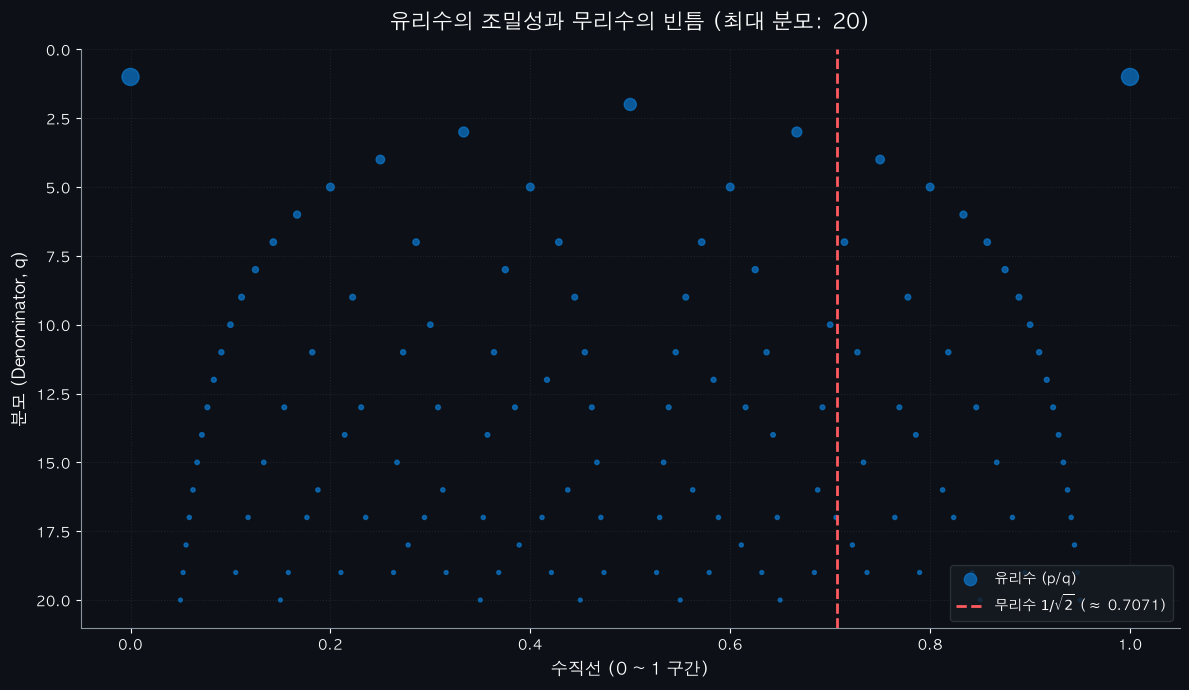

In [ ]:
def plot_rational_density(max_denominator=25):
    plt.figure(figsize=(12, 7), facecolor='#0D1117') # 도화지크기, 배경색상
    ax = plt.subplot(111) # 1개의 그래프 공간 (1행 1열의 첫번째)
    ax.set_facecolor('#0D1117')
    
    rationals_x = []
    rationals_y = []
    
    for q in range(1, max_denominator + 1):
        for p in range(0, q + 1):
            # 기약분수만 필터링하여 중복 점 제거
            frac = Fraction(p, q)
            if frac.denominator == q:
                val = p / q
                rationals_x.append(val)
                rationals_y.append(q)
                
    # 유리수 분포 점으로 표현 (분모가 작을수록 더 크고 뚜렷하게)
    sizes = [150 / y for y in rationals_y]
    ax.scatter(rationals_x, 
               rationals_y, 
               color='#0B79D0', 
               s=sizes, 
               alpha=0.7, 
               zorder=2, 
               label='유리수 (p/q)')
    
    # 대표적인 무리수 1/sqrt(2) 표시
    irrational_val = 1 / np.sqrt(2)
    ax.axvline(irrational_val, 
               color='#ff5a5f', 
               linestyle='--', 
               linewidth=2, 
               zorder=3,
               label=r'무리수 $1/\sqrt{2}$ ($\approx$ ' + f'{irrational_val:.4f})')
    
    # 축 및 꾸미기
    ax.set_title(f"유리수의 조밀성과 무리수의 빈틈 (최대 분모: {max_denominator})", color='white', fontsize=15, pad=15)
    ax.set_xlabel("수직선 (0 ~ 1 구간)", color='white', fontsize=12)
    ax.set_ylabel("분모 (Denominator, q)", color='white', fontsize=12)
    
    ax.tick_params(colors='white')
    ax.spines['bottom'].set_color('#8B949E')
    ax.spines['left'].set_color('#8B949E')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.grid(color='#30363D', linestyle=':', alpha=0.5)
    ax.set_ylim(max_denominator + 1, 0)  # 분모가 작을수록 위에 그리도록 Y축 반전
    
    legend = ax.legend(loc='lower right', facecolor='#161B22', edgecolor='#30363D', labelcolor='white')
    plt.tight_layout()
    plt.show()

# 실행
plot_rational_density(max_denominator=20)


## 실습 2. 피타고라스 화음 (Pythagorean Harmonics)

피타고라스는 두 음의 진동수 비율이 **지극히 단순한 정수비(유리수)**를 이룰 때 인간의 뇌가 그것을 가장 조화로운 '협화음(Consonance)'으로 받아들인다는 것을 발견했습니다.
- **완전 1도 (Unison)** - $1:1$ 비율
- **옥타브 (Octave)** - $2:1$ 비율
- **완전 5도 (Perfect 5th)** - $3:2$ 비율 (예: 도와 솔)
- **완전 4도 (Perfect 4th)** - $4:3$ 비율 (예: 도와 파)

반면, 비율이 무리수(예: $1:\sqrt{2}$ 등)로 떨어지거나 복잡한 합성수 비율을 이루면 파동이 불규칙하게 흐트러져 '불협화음(Dissonance)'으로 들리게 됩니다.
아래 코드는 이러한 파동의 중첩 현상을 눈으로 관찰하고, 직접 들어볼 수 있는 오디오 클립을 생성합니다.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import platform

# 기본 주파수 (A3, 220Hz)
f0 = 220.0
duration = 2.0  # 재생 시간 (초)
sample_rate = 8000  # 오디오 샘플링 레이트 (Hz)
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)

def get_wave(freq, amplitude=0.5):
    return amplitude * np.sin(2 * np.pi * freq * t)

# 1. 협화음 (완전 5도 - 3:2 비율)
f_perfect_5th = f0 * (3 / 2)  # 330Hz (E4)
wave_consonance = get_wave(f0) + get_wave(f_perfect_5th)

# 2. 불협화음 (증4도/트라이톤 - 무리수 1:sqrt(2) 비율)
f_dissonance = f0 * np.sqrt(2)  # 약 311.13Hz
wave_dissonance = get_wave(f0) + get_wave(f_dissonance)

# 파형 시각화 (초기 일부 구간만)
t_plot = t[t < 0.03]  # 약 30ms 구간만 플롯
wave_plot_f0 = get_wave(f0)[t < 0.03]
wave_plot_5th = get_wave(f_perfect_5th)[t < 0.03]
wave_plot_diss = get_wave(f_dissonance)[t < 0.03]

plt.figure(figsize=(14, 8), facecolor='#0D1117')

# 1. 협화음 플롯
ax1 = plt.subplot(2, 1, 1)
ax1.set_facecolor('#0D1117')
ax1.plot(t_plot * 1000, wave_plot_f0, color='#8B949E', linestyle=':', label=f'기본음 A3 ({f0}Hz)')
ax1.plot(t_plot * 1000, wave_plot_5th, color='#ffd166', linestyle='--', label=f'완전5도 E4 ({f_perfect_5th}Hz, 3:2 비율)')
ax1.plot(t_plot * 1000, wave_consonance[t < 0.03], color='#2FA85D', linewidth=2.5, label='합성 파형 (완전5도 화음)')
ax1.set_title("피타고라스 협화음 (완전 5도, 3:2 비율): 정교한 대칭과 주기성 형성", color='white', fontsize=14)
ax1.tick_params(colors='white')
ax1.legend(loc='upper right', facecolor='#161B22', edgecolor='#30363D', labelcolor='white')
ax1.grid(color='#30363D', alpha=0.3)

# 2. 불협화음 플롯
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
ax2.set_facecolor('#0D1117')
ax2.plot(t_plot * 1000, wave_plot_f0, color='#8B949E', linestyle=':', label=f'기본음 A3 ({f0}Hz)')
ax2.plot(t_plot * 1000, wave_plot_diss, color='#ffd166', linestyle='--', label=f'불협화음 ({f_dissonance:.2f}Hz, 1:√2 비율)')
ax2.plot(t_plot * 1000, wave_dissonance[t < 0.03], color='#ff5a5f', linewidth=2.5, label='합성 파형 (불협화음)')
ax2.set_title("무리수 비율의 불협화음 (1:√2 비율): 깨져버린 주기성과 불규칙한 파동", color='white', fontsize=14)
ax2.tick_params(colors='white')
ax2.set_xlabel("시간 (ms)", color='white', fontsize=12)
ax2.legend(loc='upper right', facecolor='#161B22', edgecolor='#30363D', labelcolor='white')
ax2.grid(color='#30363D', alpha=0.3)

plt.tight_layout()
plt.show()

# 오디오 사운드 재생 제안
print("🔊 [완전5도 협화음 (3:2 유리수비)] 들어보기:")
display(Audio(wave_consonance, rate=sample_rate))

print("🔊 [무리수 비율 (1:√2) 불협화음] 들어보기:")
display(Audio(wave_dissonance, rate=sample_rate))
